In [1]:
from rich import print as pprint
from rich.progress import track

import os
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from datasets import load_dataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import numpy as np
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from numpy.linalg import svd, norm
import gc

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '7'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [3]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B")
# model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B").to(device)

model.eval()

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  5.16it/s]


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

# Get task vectors

In [4]:
hooks = []

activations = {}
def get_activation(name):
    def hook(model, input, output):
        head_shape = output[0].shape
        # head_shape = tuple(list(output[0].shape[:-1]) + [-1, model.head_dim])
        # if (name in activations):
        #     activations[name].append(output[0].reshape(head_shape))
        # else:
        #     activations[name] = [output[0].reshape(head_shape)]
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [5]:
gen_prompts = ['Who is Harry Potter?', 
               'How old was Harry Potter when he went to Hogwarts?',
               'Who is Hermione Granger', 
               'In Harry Potter, What is the name of Harry’s owl?',
               'In Harry Potter, Who is the headmaster of Hogwarts for most of the series?',
               'In Harry Potter, What platform does the Hogwarts Express leave from?',
               'Harry Potter is a fictional character and the main ',
            #    'Who is J. K. Rowling?', 
            #    'What is the profession of J. K. Rowling?',
               'What is a hobbit?',
               'What is Lord of the Rings?',
               'Who is Aragorn?',
               'What is the one ring to rule them all?',
               'What was Sauron’s ultimate goal, beyond ruling Middle-earth?',
               'What makes Gandalf different from Saruman, even though they are both Istari?',
               'What if Frodo had kept the Ring at Mount Doom?',
            #    'Who is J. R. R. Tolkien?',
            #    'What is the profession of J. R. R. Tolkien?',
               'How was Narnia created, and what role did Aslan play in its origin?',
               'What is the significance of the Deep Magic and the Deeper Magic in The Lion, the Witch, and the Wardrobe?',
               'How would Narnia have been different if the Pevensies had stayed as rulers?',
               'In what ways does Narnia reflect themes of sacrifice and redemption?',
               'How do the different worlds (Narnia, Earth, Charn, etc.) connect within C.S. Lewis’ universe?',
               'Why is Eustace Scrubb’s transformation in The Voyage of the Dawn Treader significant?',
               'What does Narnia say about the nature of good and evil?',
            #    'How does C.S. Lewis use allegory in his storytelling?',
            #    'What is the profession of C.S. Lewis?',
               'How does the Force work, and what are the differences between the Light and Dark Side?',
               'What are the origins of the Sith, and how do they differ from the Jedi?',
               'How does Anakin Skywalker’s fall compare to other tragic heroes in literature?',
               'What motivates Emperor Palpatine beyond power?',
               'How does Ahsoka Tano’s character challenge traditional Jedi beliefs?',
               'What role does destiny play in Star Wars, and is it possible to escape it?',
               'How would the story change if Qui-Gon Jinn had survived The Phantom Menace?',]


gen_labels = 7*['Harry Potter'] + 7*['Lord of the Rings'] + 7*['Narnia'] + 7*['Star Wars']

In [6]:
ds = load_dataset("greengerong/leetcode")['train']

In [7]:
for_prompts = []
for_labels = []

keep = 7

for l in ['java', 'c++', 'python', 'javascript']:
    for i in tqdm(range(min(keep, len(ds)))):
        for_prompts.append(ds[i][l].split('```')[1])
        for_labels.append(l)

100%|██████████| 7/7 [00:00<00:00, 18045.56it/s]


In [8]:
hidden_states = []
total_labels = []

activations = {}

for i, p in tqdm(enumerate(gen_prompts), total=len(gen_prompts)):

    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=200, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
            
    # print (tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])

    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()

    hidden_states.append(copy.deepcopy(activations))
    total_labels.append(gen_labels[i])
    activations = {}



for i, p in tqdm(enumerate(for_prompts), total=len(for_prompts)):
    
    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        model.forward(inputs.to(device))

    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()

    hidden_states.append(copy.deepcopy(activations))
    total_labels.append(for_labels[i])
    activations = {}


    

  0%|          | 0/28 [00:00<?, ?it/s]/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Starting from v4.46, the `logits` model output will have the same type as 

In [9]:
# for k, v in hidden_states.items():
#     print (k, v[0].shape)

## Task vectors explr

In [9]:
target_layers = [i for i in range(len(model.model.layers))]

# all_prompts_prototypes = {p: {target_layer: 
#                             #   torch.quantile(hidden_states[p][target_layer][0][:-1], 0.5, dim=-2).to(device)
#                               torch.mean(hidden_states[i][target_layer][0], dim=-2).to(device)
#                               for target_layer in target_layers}
#                           for i, p in enumerate(gen_prompts)}


all_prompts_prototypes = [{target_layer: 
                            #   torch.quantile(hidden_states[p][target_layer][0][:-1], 0.5, dim=-2).to(device)
                              torch.mean(hidden_states[i][target_layer][0], dim=-2).to(device)
                              for target_layer in target_layers}
                          for i in range(len(hidden_states))]


In [11]:
dis = np.zeros((len(gen_prompts), len(gen_prompts)))
cs = np.zeros((len(gen_prompts), len(gen_prompts)))

cs_func = nn.CosineSimilarity(dim=-1)
target_layer = 19


for i in range(len(gen_prompts)):
    for j in range(len(gen_prompts)):
        dis[i, j] = torch.linalg.norm(all_prompts_prototypes[gen_prompts[i]][target_layer] - all_prompts_prototypes[gen_prompts[j]][target_layer])
        cs[i, j] = cs_func(all_prompts_prototypes[gen_prompts[i]][target_layer], all_prompts_prototypes[gen_prompts[j]][target_layer])

TypeError: list indices must be integers or slices, not str

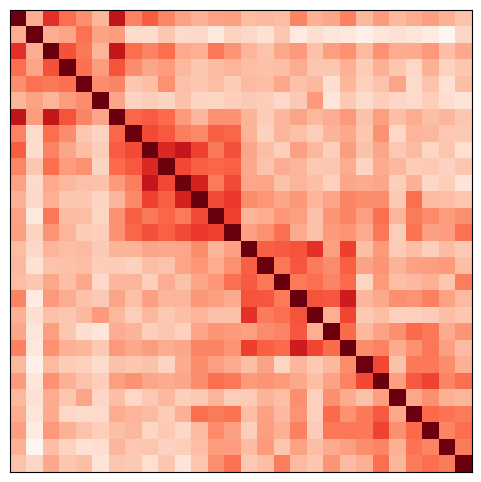

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(cs, cmap='Reds')
# for (j,i),label in np.ndenumerate(cs):
#     ax.text(i, j, '%.1f' %(label), ha='center', va='center')
# plt.xticks([i for i in range(len(questions))], [p[:40] for p in questions], rotation=90)
# plt.yticks([i for i in range(len(questions))], [p[:40] for p in questions], rotation=0)
plt.xticks([])
plt.yticks([])
plt.show()

In [10]:
target_layer = 24

original_prototypes = []
for i in range(len(all_prompts_prototypes)):
    original_prototypes.append(all_prompts_prototypes[i][target_layer])
original_prototypes = torch.stack(original_prototypes, dim=0)

In [11]:
original_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=8, random_state=0).fit_transform(original_prototypes.detach().cpu().to(float).numpy())

In [12]:
# cur_prototypes_emb

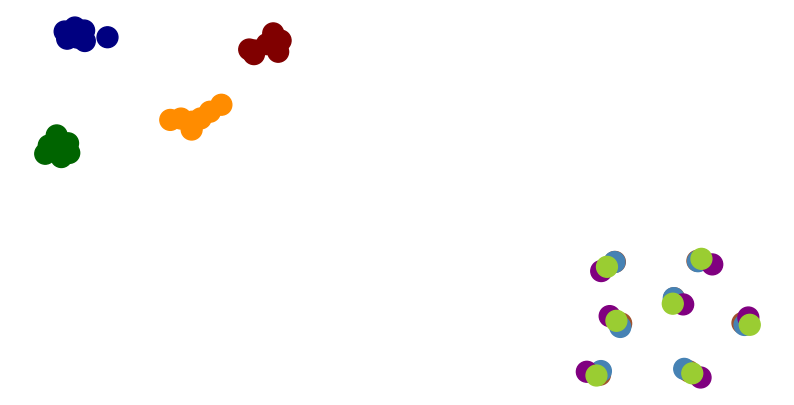

In [13]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (10, 5)


colors = []
for i in range(len(total_labels)):
    if (total_labels[i] == 'Harry Potter'):
        colors.append('maroon')
    elif (total_labels[i] == 'Lord of the Rings'):
        colors.append('darkgreen')
    elif (total_labels[i] == 'Narnia'):
        colors.append('navy')
    elif (total_labels[i] == 'Star Wars'):
        colors.append('darkorange')
    elif (total_labels[i] == 'python'):
        colors.append('purple')
    elif (total_labels[i] == 'java'):
        colors.append('sienna')
    elif (total_labels[i] == 'c++'):
        colors.append('steelblue')
    elif (total_labels[i] == 'javascript'):
        colors.append('yellowgreen')
    else:
        colors.append('black')
    


plt.scatter(original_prototypes_emb[:, 0], original_prototypes_emb[:, 1], c=colors)
plt.xticks([])
plt.yticks([])
plt.show()

## IFS

In [14]:
for hook in hooks:
    hook.remove()

In [15]:
del model

In [16]:
gc.collect()
torch.cuda.empty_cache()

In [17]:
X = []
for i in range(len(gen_prompts)):
    X.append(all_prompts_prototypes[i][0])
X = torch.stack(X, dim=0)

Y = []
for i in range(len(gen_prompts)):
    Y.append(all_prompts_prototypes[i][24])
Y = torch.stack(Y, dim=0)

In [18]:
X.shape, Y.shape

(torch.Size([28, 4096]), torch.Size([28, 4096]))

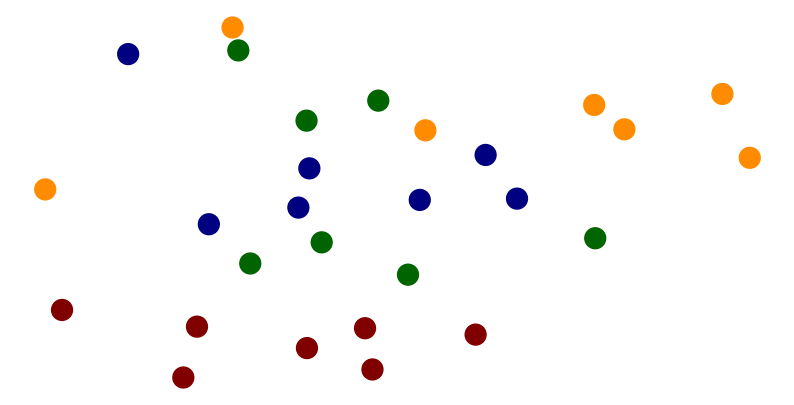

In [19]:
cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=8, random_state=0).fit_transform(X.detach().to(float).cpu().numpy())


plt.scatter(cur_prototypes_emb[:, 0], cur_prototypes_emb[:, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] + 7*['darkorange'])
plt.xticks([])
plt.yticks([])
plt.show()

In [20]:
def spectral_norm_projection(A, rho=0.99):
    """Project matrix A onto the spectral norm ball of radius rho, robust to SVD failures."""
    
    try:
        U, S, Vt = svd(A, full_matrices=False)
        S_clipped = np.minimum(S, rho)
        return U @ np.diag(S_clipped) @ Vt
    except np.linalg.LinAlgError:
        # Fallback: return scaled-down A
        A_norm = norm(A, 2)
        if A_norm == 0:
            return A
        scale = min(rho / A_norm, 1.0)
        return A * scale

def fit_contraction(X, Y, rho=0.99, max_iter=100, lr=1e-2):
    """Fit a linear map A with spectral norm < rho to minimize ||AX - Y||^2."""
    d = X.shape[1]
    A = np.random.randn(d, d) * 0.01  # Small random init
    for _ in tqdm(range(max_iter)):
        grad = 2 * (A @ X.T - Y.T) @ X  # Gradient of ||AX - Y||^2
        A -= lr * grad
        A = spectral_norm_projection(A, rho)  # Ensure contraction
    return A

def alternating_contraction_fitting(X, Y, k=3, rho=0.99, max_iter=100):
    """
    Cluster vector pairs into k groups, each with its own contraction map A_j,
    such that A_j approximately maps all x_i in its group to corresponding y_i.
    
    Args:
        X: array of shape (n, d), source vectors
        Y: array of shape (n, d), target vectors
        k: number of contraction maps
        rho: upper bound on spectral norm (should be < 1)
        max_iter: number of alternating optimization rounds
    
    Returns:
        A_list: list of fitted contraction matrices A_j
        sigma: assignment array of shape (n,), indicating which A_j is used for each pair
    """
    n, d = X.shape
    sigma = np.random.choice(k, size=n)  # initial random assignments
    A_list = [np.eye(d) * 0.01 for _ in range(k)]  # initial small maps

    # Step 1: Fit maps A_j to each cluster
    for j in range(k):
        A_list[j] = fit_contraction(X, Y, rho=rho, max_iter=max_iter)

    # Step 2: Reassign each pair to the best fitting map
    errors = np.zeros((n, k))
    for j in range(k):
        AX = X @ A_list[j].T
        errors[:, j] = np.sum((AX - Y) ** 2, axis=1)
    sigma = np.argmin(errors, axis=1)

    return A_list, sigma

In [21]:
A1, sigma1 = alternating_contraction_fitting(X[:7, :].detach().to(float).cpu().numpy(), Y[:7, :].detach().to(float).cpu().numpy(), max_iter=30)
A2, sigma2 = alternating_contraction_fitting(X[7:14, :].detach().to(float).cpu().numpy(), Y[7:14, :].detach().to(float).cpu().numpy(), max_iter=30)
A3, sigma3 = alternating_contraction_fitting(X[14:21, :].detach().to(float).cpu().numpy(), Y[14:21, :].detach().to(float).cpu().numpy(), max_iter=30)
A4, sigma4 = alternating_contraction_fitting(X[21:, :].detach().to(float).cpu().numpy(), Y[21:, :].detach().to(float).cpu().numpy(), max_iter=30)

100%|██████████| 30/30 [04:12<00:00,  8.43s/it]


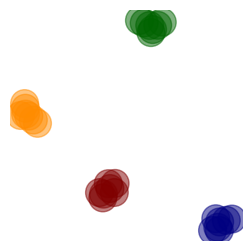

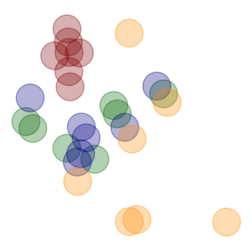

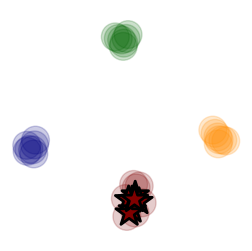

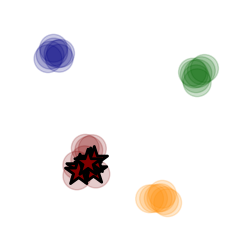

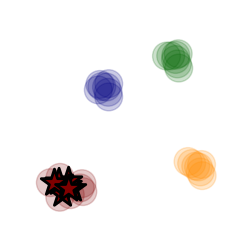

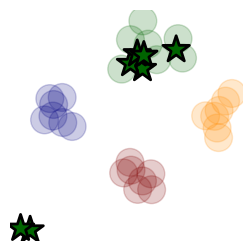

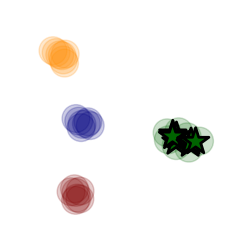

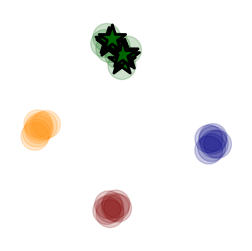

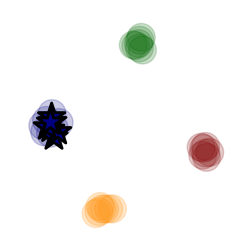

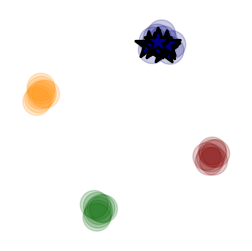

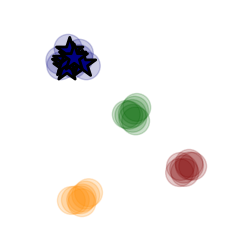

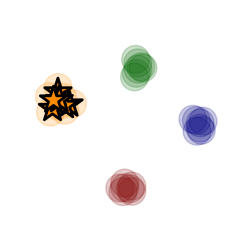

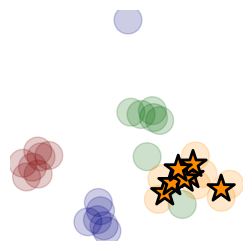

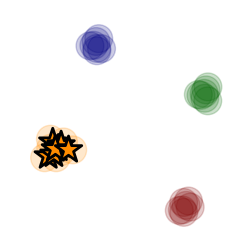

In [43]:
rcParams['figure.figsize'] = (3, 3)
rcParams['lines.markersize'] = 20
rcParams['figure.frameon'] = False


new_X = original_prototypes[:28, :].detach().cpu().to(float)

cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=2, random_state=0).fit_transform(new_X)

plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] +  7*['darkorange'], alpha=0.5)
plt.xticks([])
plt.yticks([])
plt.show()


new_X = X[:28, :].detach().cpu().to(float)

cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=2, random_state=0).fit_transform(new_X)

plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] +  7*['darkorange'], alpha=0.3)
plt.xticks([])
plt.yticks([])
plt.xlim((cur_prototypes_emb[:, 0].min()-50, cur_prototypes_emb[:, 0].max()+50))
plt.ylim((cur_prototypes_emb[:, 1].min()-50, cur_prototypes_emb[:, 1].max()+50))
plt.show()



for A in A1:

    new_X = torch.vstack((torch.Tensor(original_prototypes[:28, :]).detach().cpu().to(float), torch.Tensor(X[:7, :].detach().to(float).cpu().numpy()@ A.T)))

    cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=2, random_state=0).fit_transform(new_X)

    # plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 21*['black'],alpha=0.1)
    plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] +  7*['darkorange'],alpha=0.2)
    plt.scatter(cur_prototypes_emb[28:, 0], cur_prototypes_emb[28:, 1], c=7*['maroon'], marker='*', edgecolors='black', linewidths=2)
    plt.xticks([])
    plt.yticks([])
    plt.xlim((cur_prototypes_emb[:, 0].min()-30, cur_prototypes_emb[:, 0].max()+30))
    plt.ylim((cur_prototypes_emb[:, 1].min()-30, cur_prototypes_emb[:, 1].max()+30))
    plt.show()


for A in A2:

    new_X = torch.vstack((torch.Tensor(original_prototypes[:28, :]).detach().cpu().to(float), torch.Tensor(X[7:14, :].detach().to(float).cpu().numpy()@ A.T)))

    cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=2, random_state=0).fit_transform(new_X)

    # plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['black'] + 7*['darkgreen'] + 14*['black'], alpha=0.1)
    plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] +  7*['darkorange'],alpha=0.2)
    plt.scatter(cur_prototypes_emb[28:, 0], cur_prototypes_emb[28:, 1], c=7*['darkgreen'], marker='*', edgecolors='black', linewidths=2)
    plt.xticks([])
    plt.yticks([])
    plt.xlim((cur_prototypes_emb[:, 0].min()-30, cur_prototypes_emb[:, 0].max()+30))
    plt.ylim((cur_prototypes_emb[:, 1].min()-30, cur_prototypes_emb[:, 1].max()+30))
    plt.show()


for A in A3:


    new_X = torch.vstack((torch.Tensor(original_prototypes[:28, :]).detach().cpu().to(float), torch.Tensor(X[14:21, :].detach().to(float).cpu().numpy()@ A.T)))

    cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=2, random_state=0).fit_transform(new_X)

    # plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=14*['black'] + 7*['navy'] + 7*['black'], alpha=0.1)
    plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] +  7*['darkorange'],alpha=0.2)
    plt.scatter(cur_prototypes_emb[28:, 0], cur_prototypes_emb[28:, 1], c=7*['navy'], marker='*', edgecolors='black', linewidths=2)
    plt.xticks([])
    plt.yticks([])
    plt.xlim((cur_prototypes_emb[:, 0].min()-30, cur_prototypes_emb[:, 0].max()+30))
    plt.ylim((cur_prototypes_emb[:, 1].min()-30, cur_prototypes_emb[:, 1].max()+30))
    plt.show()



for A in A4:


    new_X = torch.vstack((torch.Tensor(original_prototypes[:28, :]).detach().cpu().to(float), torch.Tensor(X[21:, :].detach().to(float).cpu().numpy()@ A.T)))

    cur_prototypes_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=2, random_state=0).fit_transform(new_X)

    # plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=21*['black'] + 7*['darkorange'], alpha=0.1)
    plt.scatter(cur_prototypes_emb[:28, 0], cur_prototypes_emb[:28, 1], c=7*['maroon'] + 7*['darkgreen'] + 7*['navy'] +  7*['darkorange'],alpha=0.2)
    plt.scatter(cur_prototypes_emb[28:, 0], cur_prototypes_emb[28:, 1], c=7*['darkorange'], marker='*', edgecolors='black', linewidths=2)
    plt.xticks([])
    plt.yticks([])
    plt.xlim((cur_prototypes_emb[:, 0].min()-30, cur_prototypes_emb[:, 0].max()+30))
    plt.ylim((cur_prototypes_emb[:, 1].min()-30, cur_prototypes_emb[:, 1].max()+30))
    plt.show()


In [17]:
# target = prompts[1]
# plt.ioff()

# plt.figure(figsize=(40, 10))
# for k in range(len(hidden_states[target])):
#     for h in range(hidden_states[target][0].shape[-2]):
#         sim = [torch.linalg.norm(hidden_states[target][k][0][i][h] - hidden_states[target][k][0][i+1][h]) for i in range(hidden_states[target][0].shape[1]-1)]
#         plt.plot(sim[1:], label=str(k) + ' ' + str(h), linewidth=4)
# plt.legend(ncol=8)
# plt.show()


In [18]:
# for k in range(14, 17):

#     plt.figure(figsize=(40, 6))
#     plt.title(str(k))

#     for p in prompts:

#         if (p == target):
#             continue 

#         min_dis = float('inf')
#         for i in range(6, hidden_states[target][0].shape[1]):
#             for j in range(6, hidden_states[p][0].shape[1]):
#                 min_dis = min(min_dis, torch.linalg.norm(hidden_states[target][k][0][i] - hidden_states[p][k][0][j]))
        
#         print (p, min_dis)
#         plt.plot([i for i in range(hidden_states[target][0].shape[1])], [min_dis]*hidden_states[target][0].shape[1], '--', label=p, linewidth=3)


#     sim = [torch.linalg.norm(hidden_states[target][k][0][i] - hidden_states[target][k][0][i+1]) for i in range(hidden_states[target][0].shape[1]-1)]
#     plt.plot(sim[1:], label=target, linewidth=4)
#     plt.legend(ncol=8)
#     plt.show()

In [19]:
# for k in range(14, 20):

#     plt.figure(figsize=(40, 6))
#     plt.title(str(k))

#     prototype = torch.quantile(hidden_states[target][k][0][5:], 0.5, dim=-2)

#     for p in prompts:

#         if (p == target):
#             continue 

#         min_dis = float('inf')
#         for i in range(6, hidden_states[target][0].shape[1]):
#             for j in range(6, hidden_states[p][0].shape[1]):
#                 min_dis = min(min_dis, torch.linalg.norm(prototype - hidden_states[p][k][0][j]))
        
#         print (p, min_dis)
#         plt.plot([i for i in range(hidden_states[target][0].shape[1])], [min_dis]*hidden_states[target][0].shape[1], '--', label=p, linewidth=3)


#     sim = [torch.linalg.norm(prototype - hidden_states[target][k][0][i]) for i in range(hidden_states[target][0].shape[1])]
#     plt.plot(sim[1:], label=target, linewidth=4)
#     plt.legend(ncol=8)
#     plt.show()

# Add noise explr

In [20]:
# target = prompts[1]

# prototypes = {15: torch.quantile(hidden_states[target][15][0][1:], 0.8, dim=-2).to(device),
#               16: torch.quantile(hidden_states[target][16][0][1:], 0.8, dim=-2).to(device),
#               17: torch.quantile(hidden_states[target][17][0][1:], 0.8, dim=-2).to(device)}

# prototypes = {15: torch.mean(hidden_states[target][15][0][5:], dim=-2).to(device),
#               16: torch.mean(hidden_states[target][16][0][5:], dim=-2).to(device),
#               17: torch.mean(hidden_states[target][17][0][5:], dim=-2).to(device)}

In [21]:
# hooks = None

In [22]:
# def add_noise(layer):
#     def hook(model, input, output):
        
#         out = output[0]

#         sigma = 2
#         strength = 1/(sigma*np.sqrt(2*np.pi))*torch.exp(-(torch.linalg.norm(out - prototypes[layer], dim=-1))**2/(2*sigma**2)).squeeze()

#         if (out.shape[-2] != 1):
#             return

#         # print (strength, torch.linalg.norm(out))

#         noise = strength * torch.randn(prototypes[layer].shape).to(device) 
#         mod_out = out + noise

#         output = (mod_out, *output[1:])
#         return output

#     return hook

# if hooks is not None:
#     for hook in hooks:
#         hook.remove()

# hooks = [model.model.layers[i].self_attn.register_forward_hook(add_noise(i)) for i in range(15, 17)]
# hooks = [model.model.layers[i].register_forward_hook(add_noise(i)) for i in range(15, 17)]

In [23]:
# for p in track(prompts, total=len(prompts)):

#     inputs = tokenizer(p, return_tensors="pt").input_ids
#     outputs = model.generate(inputs.to(device), max_new_tokens=100, do_sample=True, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        
#     print (tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])

In [24]:

# for k in range(len(hidden_states[target])):
# for k in range(17, 18):
#     for h in range(hidden_states[target][0].shape[-2]):

#         plt.figure(figsize=(40, 10))
#         plt.title(str(k) + ', ' + str(h))

#         for p in prompts:

#             if (p == target):
#                 continue 

#             min_dis = float('inf')
#             for i in range(6, hidden_states[target][0].shape[1]):
#                 for j in range(6, hidden_states[p][0].shape[1]):
#                     min_dis = min(min_dis, torch.linalg.norm(hidden_states[target][k][0][i][h] - hidden_states[p][k][0][j][h]))
            
#             print (p, min_dis)
#             plt.plot([i for i in range(hidden_states[target][0].shape[1])], [min_dis]*hidden_states[target][0].shape[1], '--', label=p, linewidth=3)


#         sim = [torch.linalg.norm(hidden_states[target][k][0][i][h] - hidden_states[target][k][0][i+1][h]) for i in range(hidden_states[target][0].shape[1]-1)]
#         plt.plot(sim[1:], label=target, linewidth=4)
#         plt.legend(ncol=8)
#         plt.show()


    

# Patchscopes

In [25]:
# hook = None

In [26]:
# def add_patch(layer):
#     def hook(model, input, output):
        
#         # print (output[0].shape)

#         if (output[0].shape[-2] == 1):
#             return

#         # print (output[0].shape)

#         mod_out = output[0]
#         mod_out[0, -1, :] = prototypes[layer].to(device)

#         output = (mod_out, *output[1:])
#         # output = mod_out
#         return output

#     return hook

# if hook is not None:
#     hook.remove()

# hook = model.model.layers[16].self_attn.register_forward_hook(add_patch(16)) 



In [27]:
# for p in prompts:

#     print (p)

#     # prototypes = {15: torch.quantile(hidden_states[p][15][0][3:], 0.7, dim=-2).to(device),
#     #               16: torch.quantile(hidden_states[p][16][0][3:], 0.7, dim=-2).to(device),
#     #               17: torch.quantile(hidden_states[p][17][0][3:], 0.7, dim=-2).to(device)}

#     prototypes = {15: hidden_states[p][15][0][-1].to(device),
#                   16: hidden_states[p][16][0][-1].to(device),
#                   17: hidden_states[p][17][0][-1].to(device)}

#     # prototypes = {15: torch.mean(hidden_states[p][15][0][5:], dim=-2).to(device),
#     #             16: torch.mean(hidden_states[p][16][0][5:], dim=-2).to(device),
#     #             17: torch.mean(hidden_states[p][17][0][5:], dim=-2).to(device)}

#     inputs = tokenizer('cat->cat, 135->135, hello->hello, 6515->6515, ?', return_tensors="pt").input_ids
#     outputs = model.generate(inputs.to(device), max_new_tokens=10, do_sample=True, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        
#     print (tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])

In [28]:
# inputs.shape

In [35]:
for target_layer in range(15, 29):
    

    print ('\n\n------------------------------------------')
    print (target_layer)

    for p_idx in range(0, 28, 7):

        
        cur_prototypes = []
        for i in range(p_idx, p_idx+7):
            cur_prototypes.append(all_prompts_prototypes[gen_prompts[i]][target_layer])
        cur_prototypes = torch.stack(cur_prototypes, dim=0)
        prototype = torch.mean(cur_prototypes, dim=0)
        
        # print (p)


        top_10_tokens = torch.topk(F.softmax(model.lm_head(prototype), dim=-1), 10).indices

        
        for i, idx in enumerate(top_10_tokens):
            print (i, tokenizer.batch_decode([idx])[0])





------------------------------------------
15
0 book
1 arro
2 obook
3 ey
4 ith
5 ieux
6 ……
7  books
8  book
9 …

0 pur
1 ey
2 e
3  Boyd
4 book
5 749
6  Fel
7 Book
8 deep
9 lect
0 book
1  Wald
2 books
3 pur
4 Book
5 ichert
6 lect
7 ede
8 avel
9 adic
0 umb
1 ey
2 e
3  deep
4 deep
5 …

6 "
7  Wald
8 …
9  throughout


------------------------------------------
16
0 …

1 …
2  …

3 …”
4  […]

5 ……
6 ...

7 ….
8 …the
9 …and
0 …

1 …
2  …

3 …”
4 ….
5 …and
6 …"
7  […]

8 ……
9 …the
0 …

1  …

2 …
3 …”
4 ……
5 …and
6  […]

7 ….
8 ...

9 …the
0 …

1 …”
2  …

3 …
4 ……
5  […]

6 ….
7 …"
8 ...

9 …and


------------------------------------------
17
0 …

1 …
2 ….
3 ……
4 …”
5  […]

6  …

7 …..
8 …the
9 …"
0 …

1 …
2 ….
3 ……
4  …

5  …
6 …”
7  […]

8 [
9 …..
0 …

1 …
2 ….
3  […]

4 …”
5  …

6 ……
7 …I
8 …and
9 ,…
0 …

1 …
2 ….
3 ……
4  …

5 …and
6 …”
7  […]

8 …..
9 …the


------------------------------------------
18
0 ……
1  فه
2 strict
3 requete
4  Mundo
5 andel
6  himself
7 …..
8 …
9 …and
0 …
1 …

2 

In [22]:
tokenizer.eos_token_id

128009

# Learn noise

In [9]:
def exponential_average(vectors, alpha=0.5):

    run_mean = vectors[0]
    for i in range(1, len(vectors)):
        run_mean = alpha*vectors[i] + (1-alpha)*run_mean

    return run_mean

In [10]:
target_prompt = prompts[0]
target_layers = [14, 15, 16, 17, 18, 19, 20, 29, 30, 31]

all_prompts_prototypes = {p: {target_layer: 
                              torch.quantile(hidden_states[p][target_layer][0][1:], 0.5, dim=-2).to(device)
                              for target_layer in target_layers}
                          for p in prompts}

prototypes = {target_layer: torch.quantile(hidden_states[target_prompt][target_layer][0][1:], 0.5, dim=-2).to(device) for target_layer in target_layers}
# prototypes = {target_layer: exponential_average(hidden_states[target_prompt][target_layer][0][1:], 0.05).to(device) for target_layer in target_layers}
noises = {target_layer: nn.Parameter(torch.zeros(prototypes[target_layer].shape).to(device)) for target_layer in target_layers}

In [11]:
dis = np.zeros((len(prompts), len(prompts)))
cs = np.zeros((len(prompts), len(prompts)))

cs_func = nn.CosineSimilarity(dim=-1)
target_layer = 16


for i in range(len(prompts)):
    for j in range(len(prompts)):
        dis[i, j] = torch.linalg.norm(all_prompts_prototypes[prompts[i]][target_layer] - all_prompts_prototypes[prompts[j]][target_layer])
        cs[i, j] = cs_func(all_prompts_prototypes[prompts[i]][target_layer], all_prompts_prototypes[prompts[j]][target_layer])

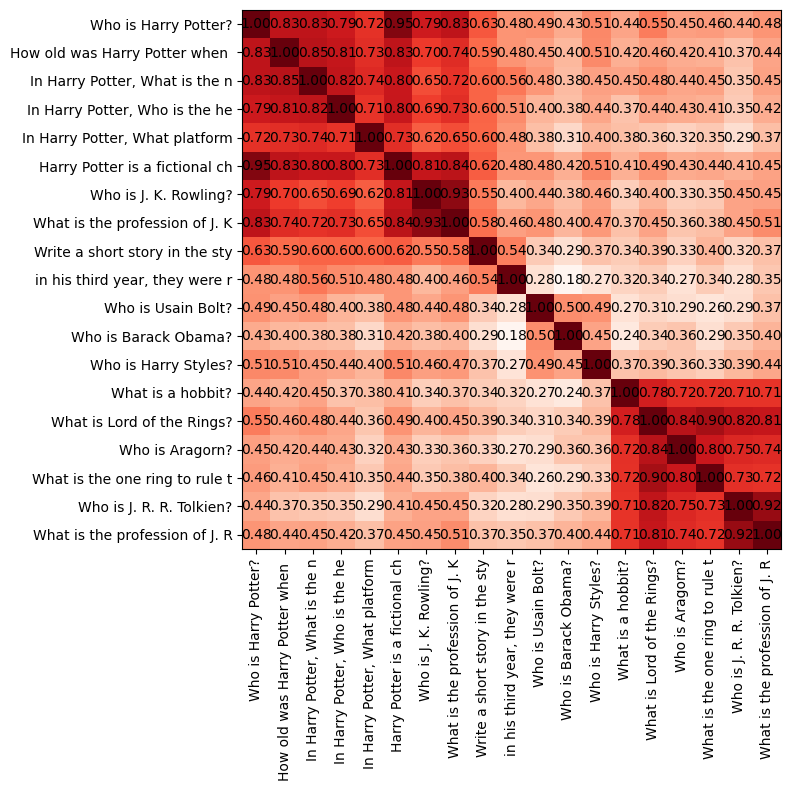

In [12]:
# fig, ax = plt.subplots()
# plt.imshow(dis)
# for (j,i),label in np.ndenumerate(dis):
#     ax.text(i, j, '%.2f' %(label), ha='center', va='center')
# plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
plt.imshow(cs, cmap='Reds')
for (j,i),label in np.ndenumerate(cs):
    ax.text(i, j, '%.2f' %(label), ha='center', va='center')
plt.xticks([i for i in range(len(prompts))], [p[:30] for p in prompts], rotation=90)
plt.yticks([i for i in range(len(prompts))], [p[:30] for p in prompts], rotation=0)
plt.show()

In [23]:
agg_prototype = {target_layer: torch.mean(torch.stack([all_prompts_prototypes[p][target_layer] for p in prompts[3:6]]), dim=0) for target_layer in target_layers}

dis = np.zeros((len(prompts)))
cs = np.zeros((len(prompts)))

cs_func = nn.CosineSimilarity(dim=-1)
target_layer = 29


for i in range(len(prompts)):
    dis[i] = torch.linalg.norm(agg_prototype[target_layer] - all_prompts_prototypes[prompts[i]][target_layer])
    cs[i] = cs_func(agg_prototype[target_layer], all_prompts_prototypes[prompts[i]][target_layer])

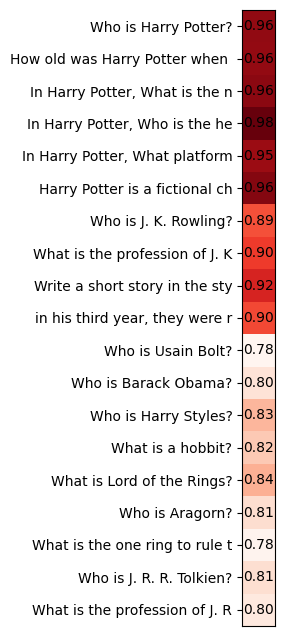

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.imshow(np.expand_dims(cs, 1), cmap='Reds')
for (j,i),label in np.ndenumerate(np.expand_dims(cs, 1)):
    ax.text(i, j, '%.2f' %(label), ha='center', va='center')
plt.yticks([i for i in range(len(prompts))], [p[:30] for p in prompts], rotation=0)
plt.xticks([])
# plt.yticks([i for i in range(len(prompts))], [p[:30] for p in prompts], rotation=0)
plt.show()

In [18]:
print (cs)
print (dis)

[0.96443498 0.93897319 0.94428951 0.76684618 0.77886862 0.93799359
 0.79018819 0.51999623 0.50294977 0.4056167  0.53403497 0.49216056
 0.53063327 0.48564982 0.4777185 ]

[0.56464493 0.56645012 0.55620599 1.08947277 1.08801913 0.72759843
 1.08999109 1.50135744 1.50410521 1.83979642 1.57088697 1.81423593
 1.79893291 1.74073613 1.8816005 ]

In [27]:
cs_target = torch.LongTensor([tokenizer.eos_token_id]).to(device)

for target_layer in target_layers:

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW([noises[target_layer]], lr=0.1, weight_decay=1e-5)

    for _ in track(range(1000)):

        out = model.lm_head(prototypes[target_layer] + noises[target_layer]).unsqueeze(0)
        loss = loss_fn(out, cs_target) + 0.01*torch.linalg.norm(noises[target_layer], 1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [28]:
for target_layer in target_layers:
    noises[target_layer] = noises[target_layer].detach()
    print (noises[target_layer].max(), noises[target_layer].min(), torch.linalg.norm(noises[target_layer]))

tensor(21.6623, device='cuda:0') tensor(-30.6902, device='cuda:0') tensor(66.0836, device='cuda:0')

tensor(21.7353, device='cuda:0') tensor(-30.6880, device='cuda:0') tensor(66.1460, device='cuda:0')

tensor(21.7116, device='cuda:0') tensor(-30.6611, device='cuda:0') tensor(66.1213, device='cuda:0')

tensor(21.7111, device='cuda:0') tensor(-30.6841, device='cuda:0') tensor(66.1240, device='cuda:0')

tensor(21.7346, device='cuda:0') tensor(-30.6979, device='cuda:0') tensor(66.1014, device='cuda:0')

tensor(21.7401, device='cuda:0') tensor(-30.7523, device='cuda:0') tensor(66.0964, device='cuda:0')

tensor(21.7658, device='cuda:0') tensor(-30.7491, device='cuda:0') tensor(66.1552, device='cuda:0')

In [29]:
for target_layer in target_layers:

    x1 = torch.where(noises[target_layer] > -0.5, 1, 0)
    x2 = torch.where(noises[target_layer] < 5, 1, 0)

    mask = x1*x2
    indices = mask.nonzero()
    noises[target_layer][indices] = 0

In [30]:
for noise in noises.values():
    print ((noise!=0).sum())

tensor(15, device='cuda:0')

tensor(15, device='cuda:0')

tensor(15, device='cuda:0')

tensor(15, device='cuda:0')

tensor(15, device='cuda:0')

tensor(15, device='cuda:0')

tensor(15, device='cuda:0')

In [33]:
# hooks = None

In [34]:
strengths = {target_layer: [] for target_layer in target_layers}
cs_func = nn.CosineSimilarity(dim=-1)

def add_noise(layer):
    
    def hook(model, input, output):
        
        out = output[0]

        sigma = 0.3
        # strength = (10000*1/(sigma*np.sqrt(2*np.pi))*torch.exp(-(torch.linalg.norm(out - prototypes[layer], dim=-1))**2/(2*sigma**2)).squeeze()).detach().cpu().tolist()
        strength = cs_func(out, prototypes[layer]).squeeze().detach().cpu().tolist()

        # if (out.shape[-2] != 1):
        #     return

        if (isinstance(strength, float)):
            strengths[layer].append(strength)
        else:
            strengths[layer].extend(strength)


        # print (strength, torch.linalg.norm(out), torch.linalg.norm(strength*noise))


        # if (isinstance(strength, float)):
        #     mod_out = out + strength*5*torch.randn(out.shape).to(out.get_device()) if strength >= 1 else 0
        # else:
        #     mod_out = out #+ strength*noises[layer]

        mod_out = out

        output = (mod_out, *output[1:])
        return output

    return hook

if hooks is not None:
    for hook in hooks:
        hook.remove()
hooks = [model.model.layers[target_layer].self_attn.register_forward_hook(add_noise(target_layer)) for target_layer in target_layers]

Output()

/home/takis/anaconda3/envs/llama/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:629: 
UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in 
sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(

/home/takis/anaconda3/envs/llama/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:634: 
UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in 
sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(

Who is Harry Potter? Harry Potter is a fictional character and the main protagonist of J.K. Rowling's beloved book 
series, "Harry Potter." He is a young wizard who attends Hogwarts School of Witchcraft and Wizardry and embarks on 
a series of adventures to save the

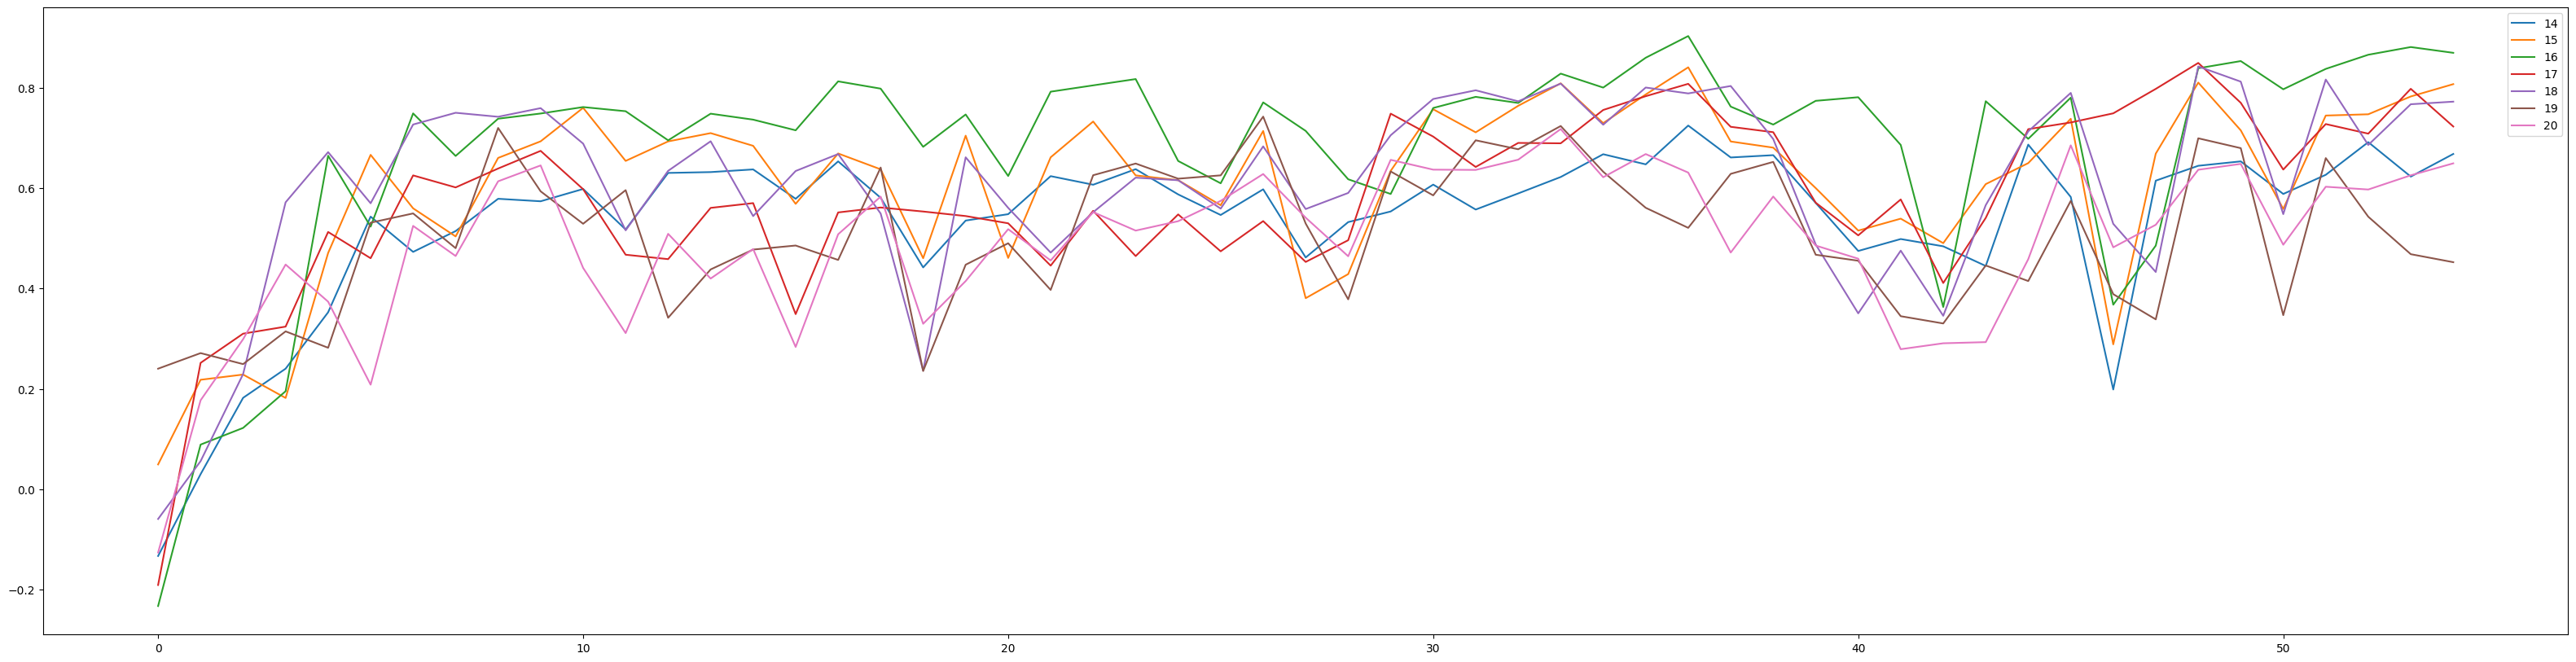

14 0.538965640115467 0.16024131371562486 0.7245175838470459 -0.13291999697685242

15 0.6112868784503503 0.169637379368611 0.8405223488807678 0.0494677796959877

16 0.6825321782719005 0.21447373146161064 0.9027793407440186 -0.2326176017522812

17 0.5814923454414714 0.1723646114797744 0.8492380380630493 -0.19069257378578186

18 0.6119765550575473 0.1861737524279272 0.842239499092102 -0.05919657647609711

19 0.5063845501704649 0.13830404095070037 0.7422958612442017 0.23557285964488983

20 0.494033639810302 0.15466825865488948 0.7175357937812805 -0.12601789832115173

Who is Hermione Granger?
Hermione Jean Granger is a fictional character in the Harry Potter fantasy series created by J.K. Rowling. She is 
one of the main protagonists of the series, along with Harry Potter and Ron Weasley. Hermione is a brilliant and 
resource

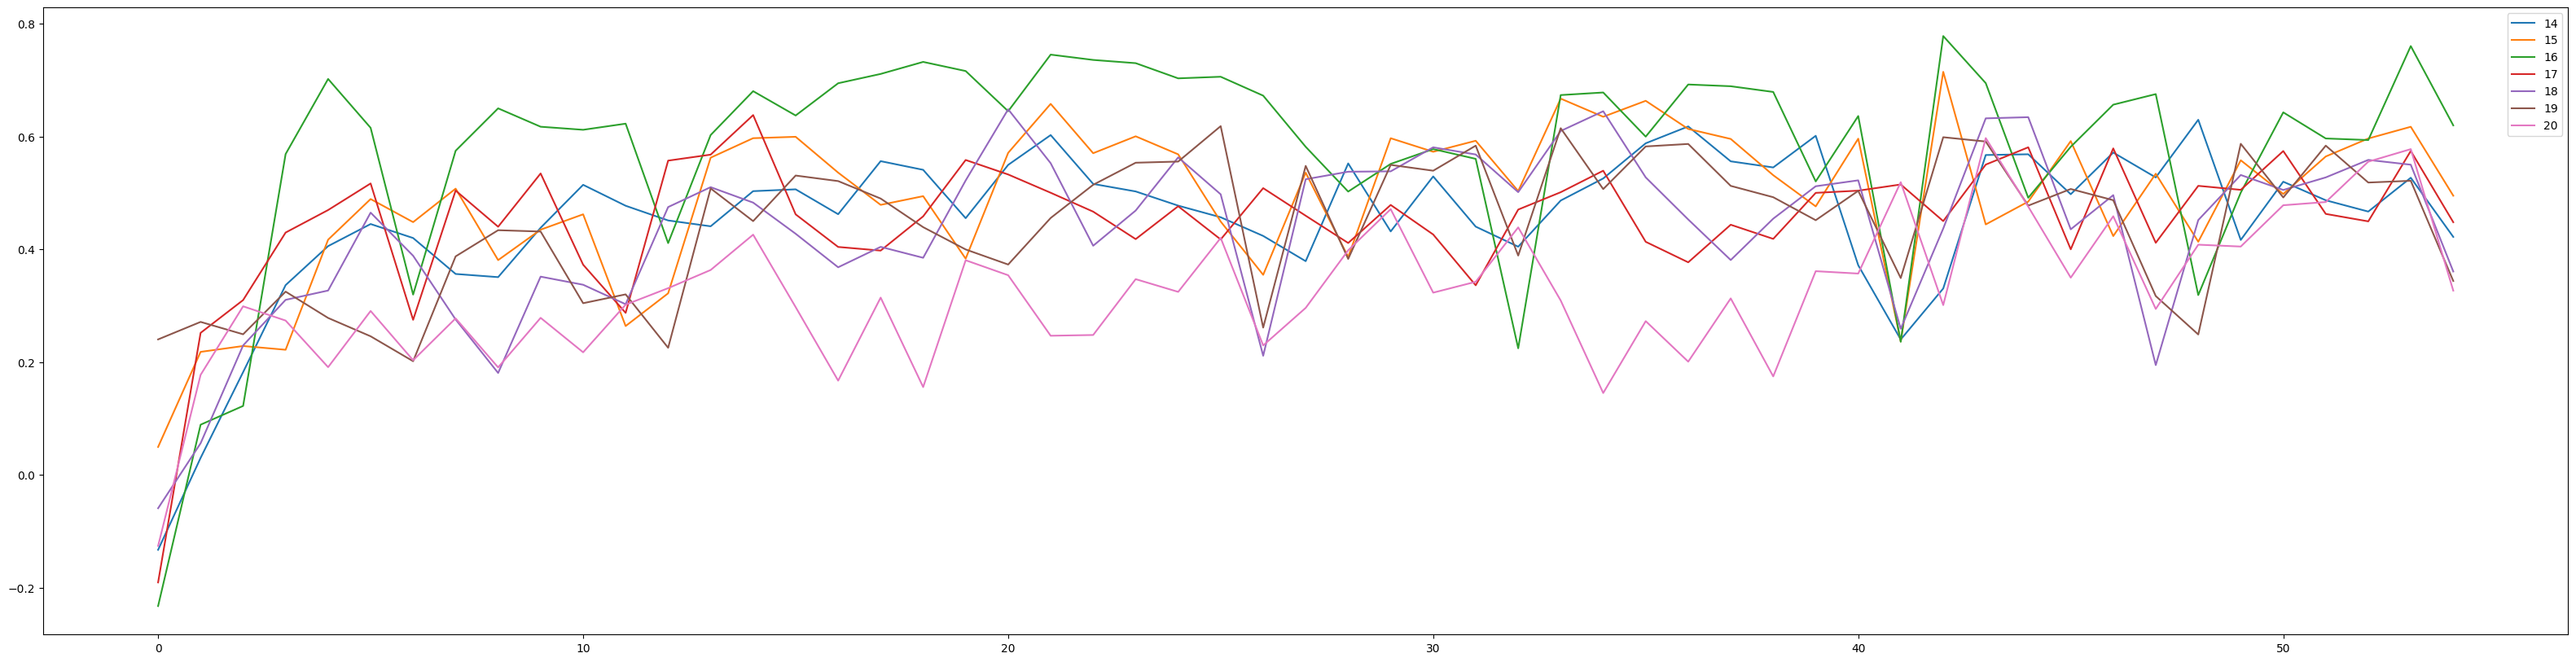

14 0.45578371648761357 0.1332629741662683 0.6296857595443726 -0.13291999697685242

15 0.4909931073134596 0.1330498338309939 0.7146881818771362 0.0494677796959877

16 0.5762970420447263 0.18760458271172048 0.778134822845459 -0.2326176017522812

17 0.45193873102014714 0.11841202894078838 0.6379806995391846 -0.19069257378578186

18 0.4366465859115124 0.14410239661016938 0.6482653617858887 -0.05919657647609711

19 0.4445425263860009 0.11873833488369048 0.6183852553367615 0.2015027403831482

20 0.3238732115788893 0.12415848530647605 0.5971988439559937 -0.12601789832115173

In Harry Potter, What is the name of Harry’s owl? In the Harry Potter series, Harry Potter has a pet owl named 
Hedwig. Hedwig is a white owl who is very loyal to Harry and plays an important role in the series. She is known 
for her gentle nature and her ability to deliver important

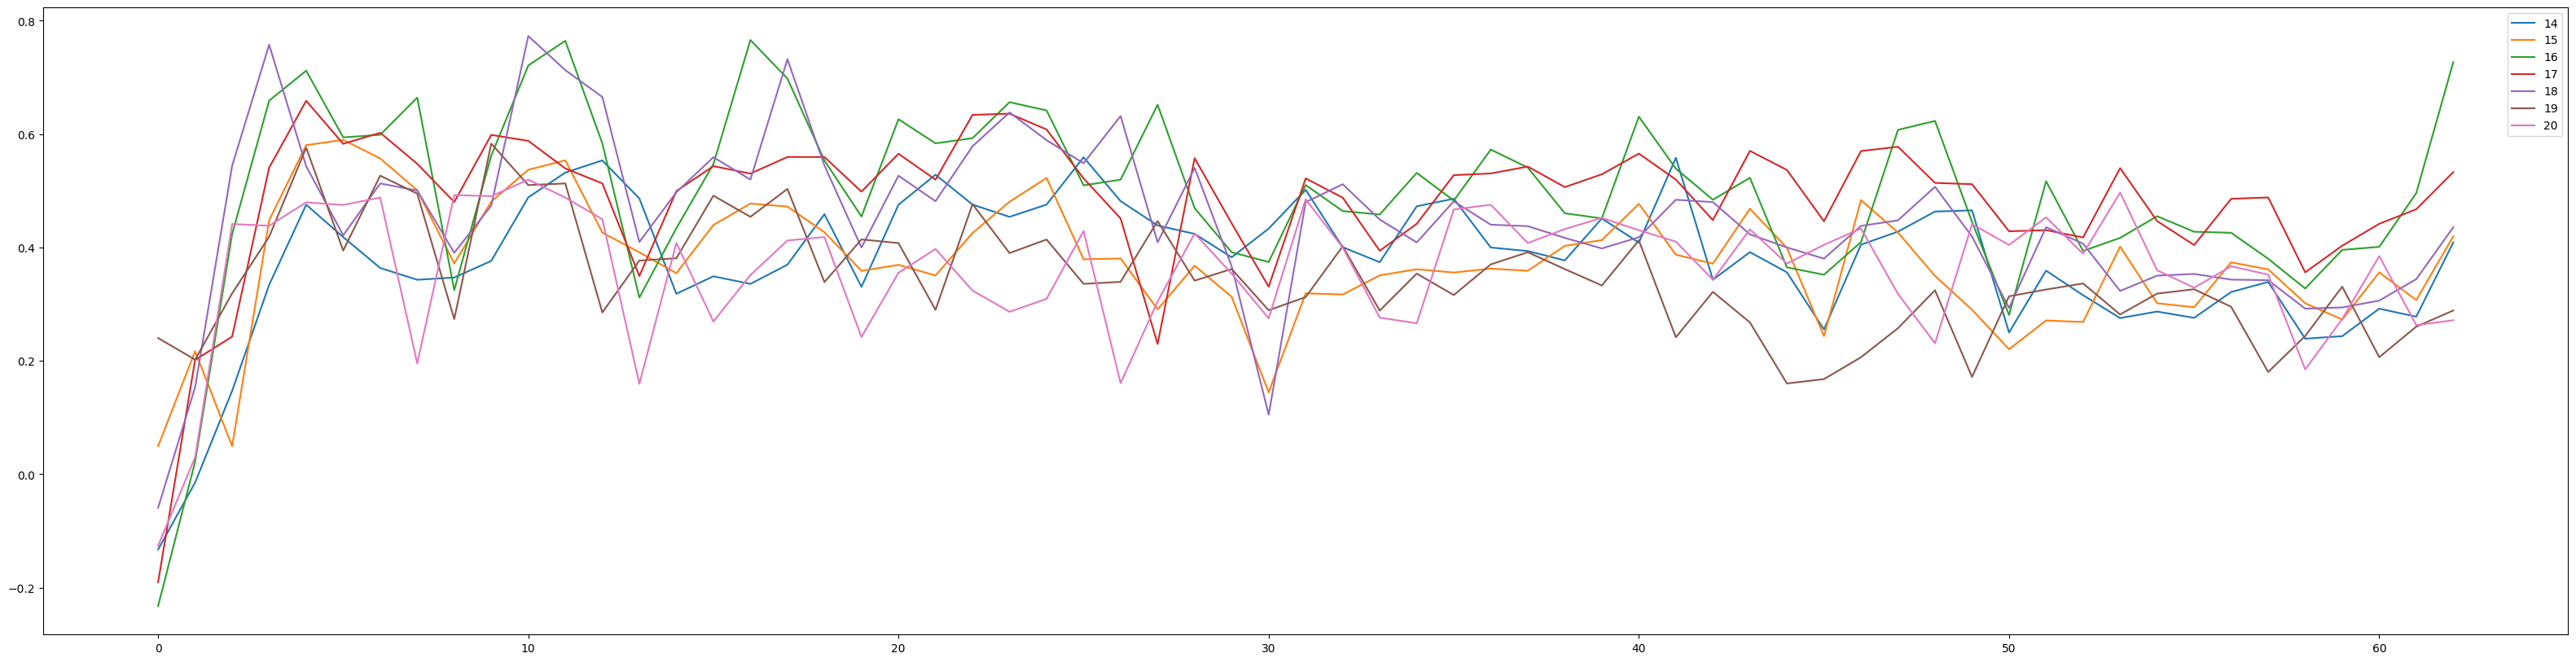

14 0.37817886158350916 0.12007495155564007 0.5591821074485779 -0.13291998207569122

15 0.3745280812893595 0.10771107421901967 0.589874804019928 0.04939206689596176

16 0.49644698711141705 0.16133911153711933 0.7660118341445923 -0.2326175719499588

17 0.4845703253670344 0.12559280631706754 0.658761203289032 -0.19069266319274902

18 0.450977575920877 0.1409974530605077 0.7729933261871338 -0.059196606278419495

19 0.3453942650840396 0.09860252035445832 0.5831361413002014 0.16004955768585205

20 0.3611086332017467 0.11687500178149972 0.5196147561073303 -0.12601791322231293

In Harry Potter, Who is the headmaster of Hogwarts for most of the series? The answer is Albus Dumbledore. He is 
the headmaster of Hogwarts School of Witchcraft and Wizardry for most of the series, until his death in the sixth 
book, "Harry Potter and the Half-Blood Prince." After his death, Sever

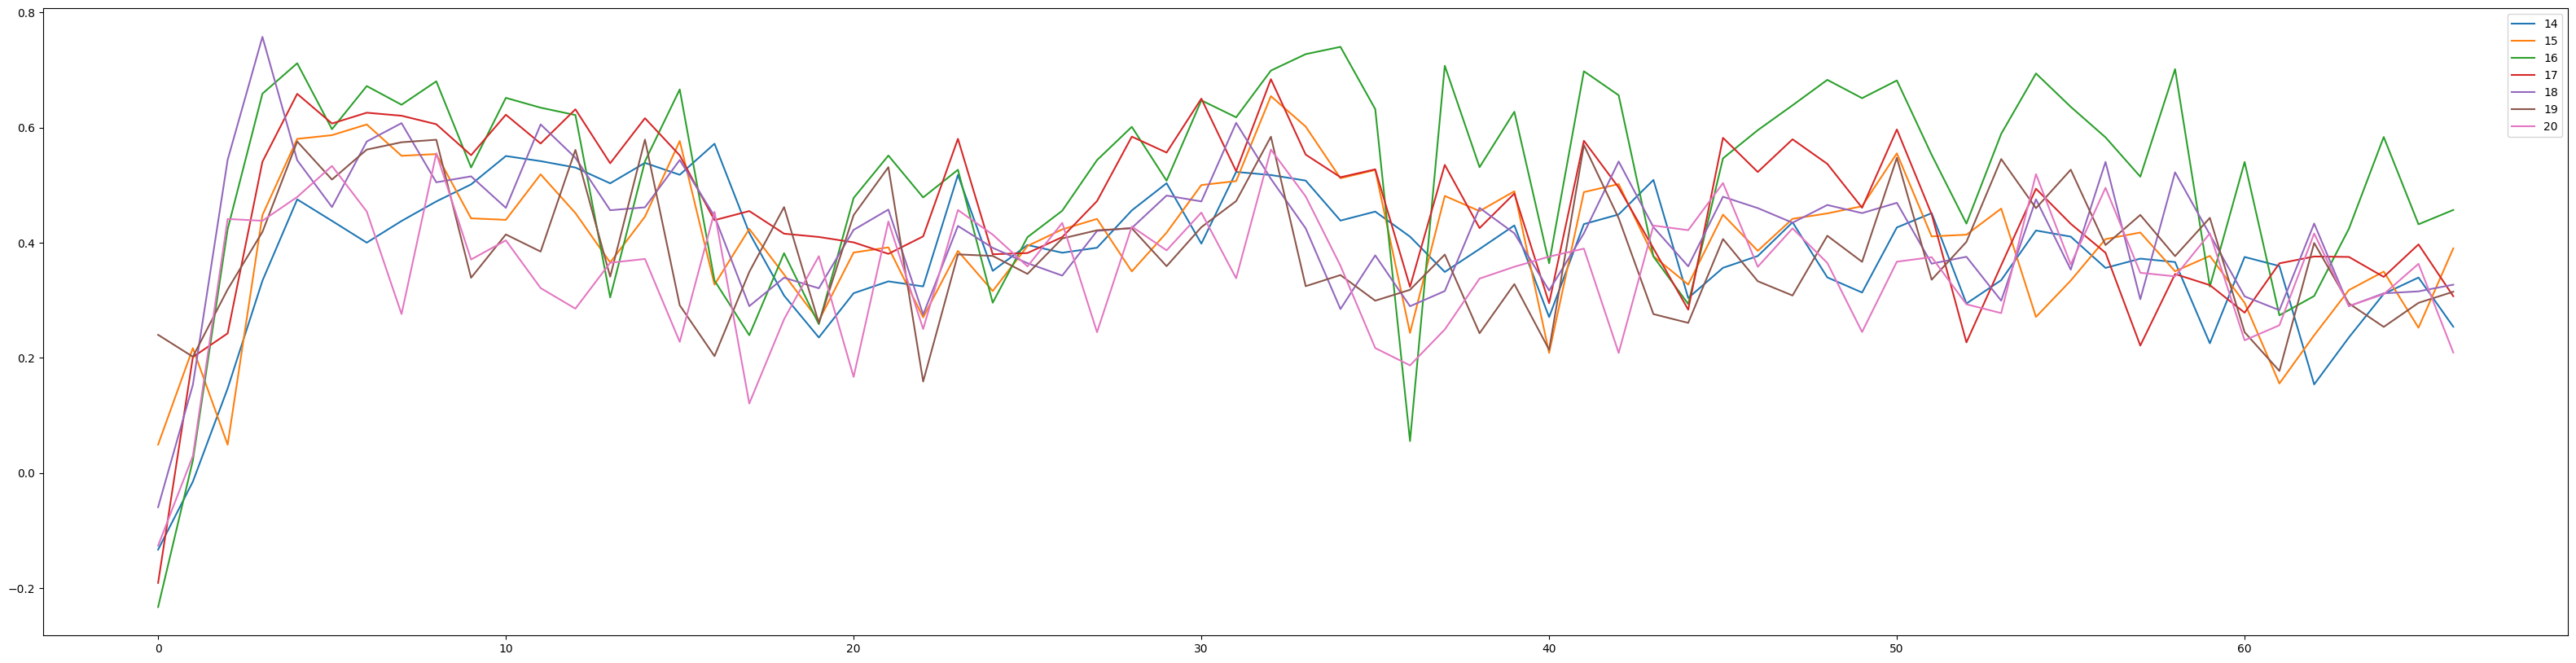

14 0.38276020476399963 0.12379798680948391 0.5721222162246704 -0.13292014598846436

15 0.4042711017736748 0.12199536497222227 0.6546981334686279 0.0493919774889946

16 0.5136275158277643 0.18364246557280572 0.7403620481491089 -0.23261764645576477

17 0.45531171827173944 0.1441677493579776 0.6841919422149658 -0.19069264829158783

18 0.41780420159226034 0.11879133087430753 0.7576960921287537 -0.059196650981903076

19 0.3850908879913501 0.11065412698148124 0.5843205451965332 0.15910053253173828

20 0.3488091149770502 0.1196344317054646 0.5618590116500854 -0.12601810693740845

In Harry Potter, What platform does the Hogwarts Express leave from? The Hogwarts Express leaves from Platform 9 
3/4 at King's Cross Station in London. However, the platform is not visible to Muggles (non-magical people) and can
only be accessed by wizards and witches who know the

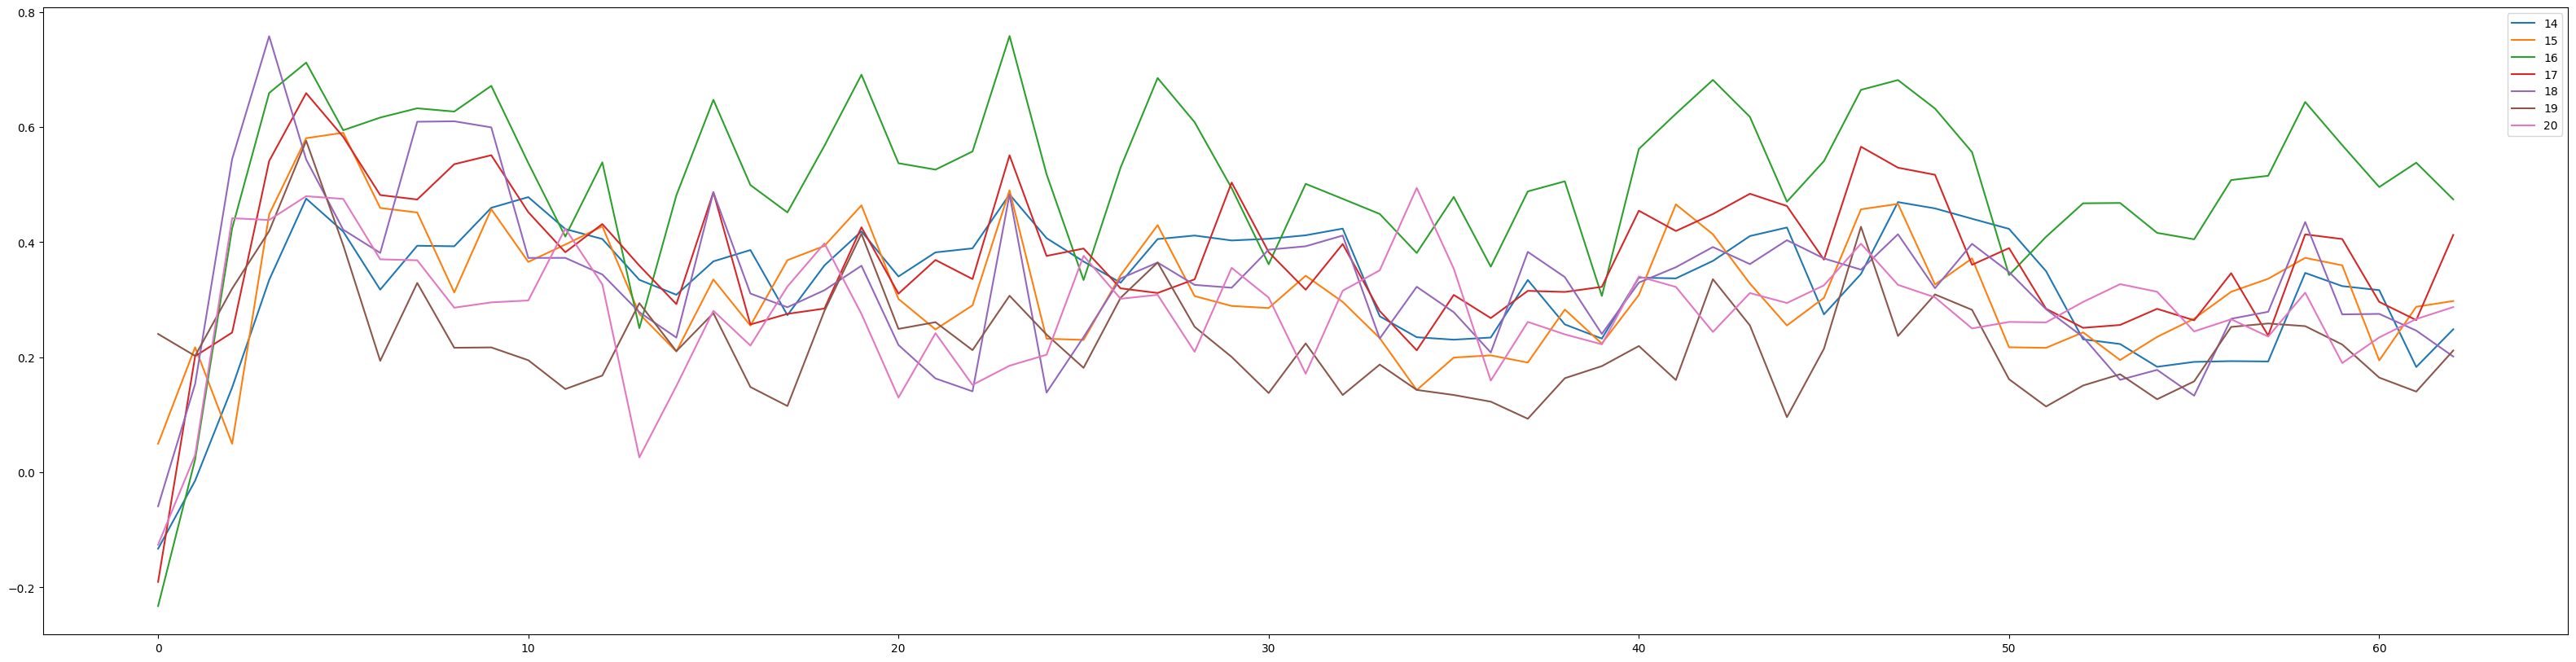

14 0.3295062003982446 0.11280103653601513 0.4827079176902771 -0.13291998207569122

15 0.31562902305334334 0.10901830671673313 0.589874804019928 0.04939206689596176

16 0.5067378283729629 0.15593999038293452 0.7579475045204163 -0.2326175719499588

17 0.3706182421199859 0.1260529164300569 0.658761203289032 -0.19069266319274902

18 0.3309439718723297 0.13287315957097418 0.7576959133148193 -0.059196606278419495

19 0.22796316338436945 0.09146677124358436 0.5759707689285278 0.09285544604063034

20 0.28118134588594473 0.1060813121693392 0.4939994215965271 -0.12601791322231293

Harry Potter is a fictional character and the main 1st-person narrator of J.K. Rowling's series of fantasy novels, 
known as the Harry Potter series. He is a young wizard who attends Hogwarts School of Witchcraft and Wizardry, and 
is known for his bravery, loyalty, and determination to

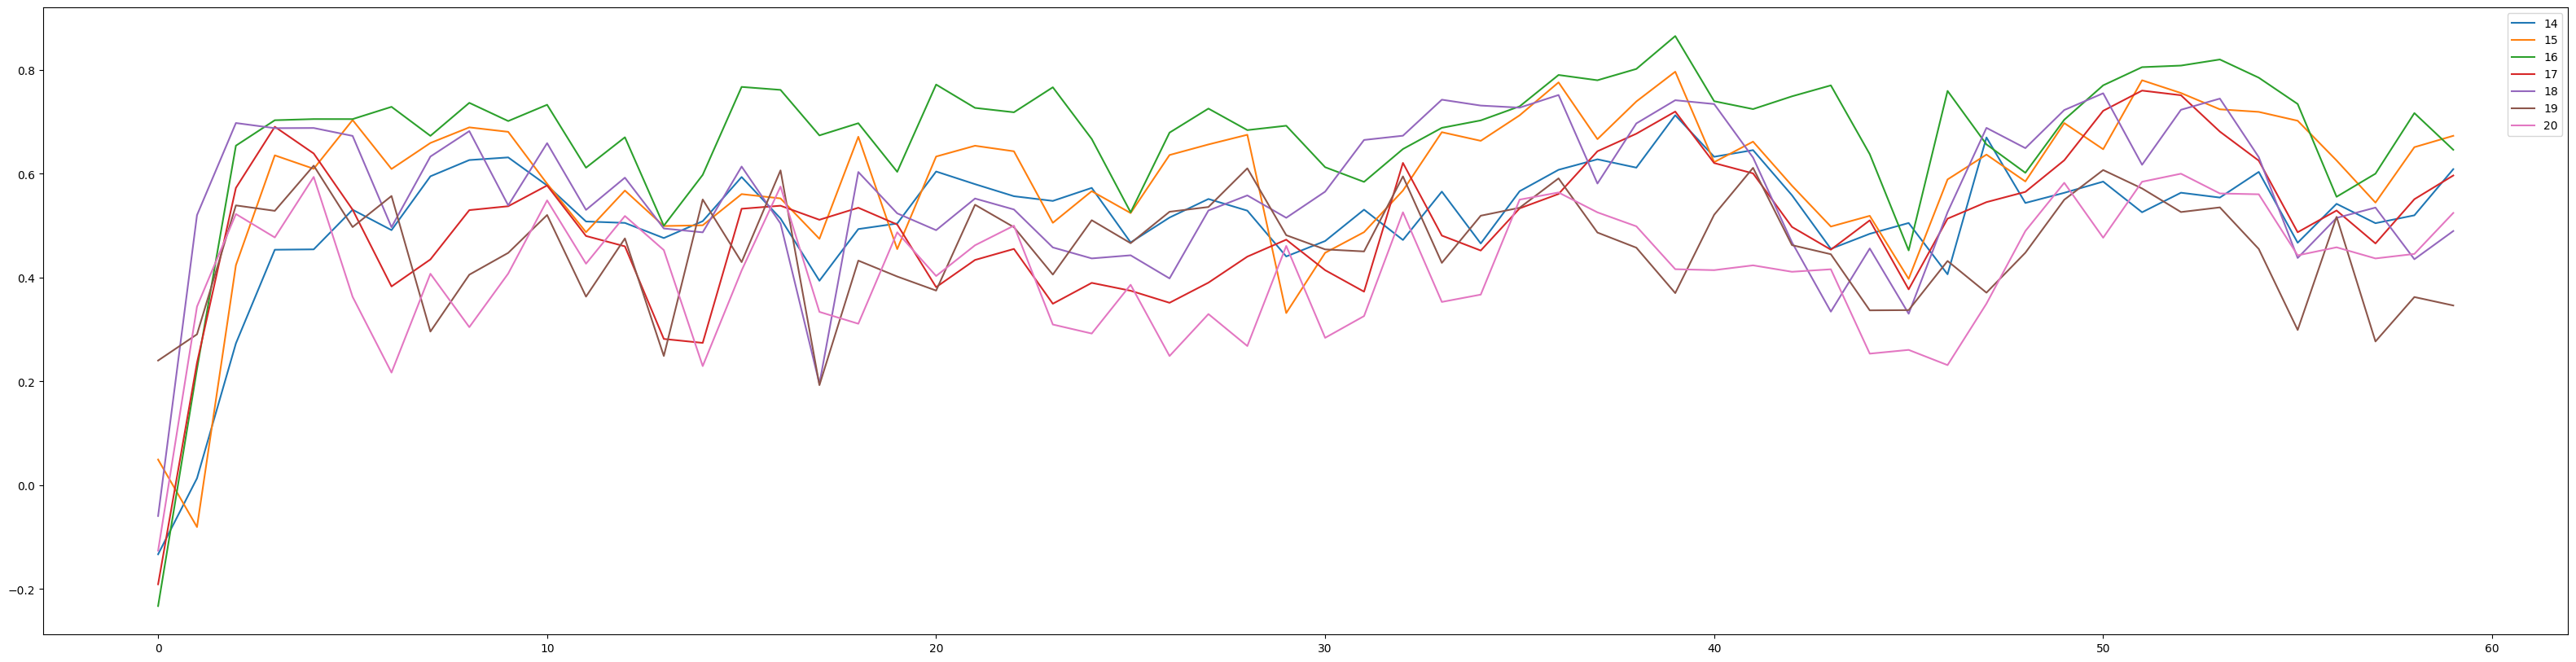

14 0.515743778894345 0.1298259354745406 0.7127014994621277 -0.13291998207569122

15 0.588272433479627 0.1494604151601169 0.7964637279510498 -0.08050498366355896

16 0.6734916890660921 0.15451791177792057 0.8651199340820312 -0.2326175719499588

17 0.5008004245658716 0.14723632931871578 0.7600991725921631 -0.19069266319274902

18 0.5662501111626626 0.14538021112458938 0.7549141645431519 -0.059196606278419495

19 0.4581110772987207 0.10229713457455575 0.6156039834022522 0.19281335175037384

20 0.4133870000640551 0.12631900343332553 0.600023090839386 -0.12601791322231293

Who is J. K. Rowling? J.K. Rowling is a British author, screenwriter, and philanthropist best known for writing the
Harry Potter fantasy series. She is one of the most successful authors in the world, with over 500 million copies 
of her books sold worldwide.

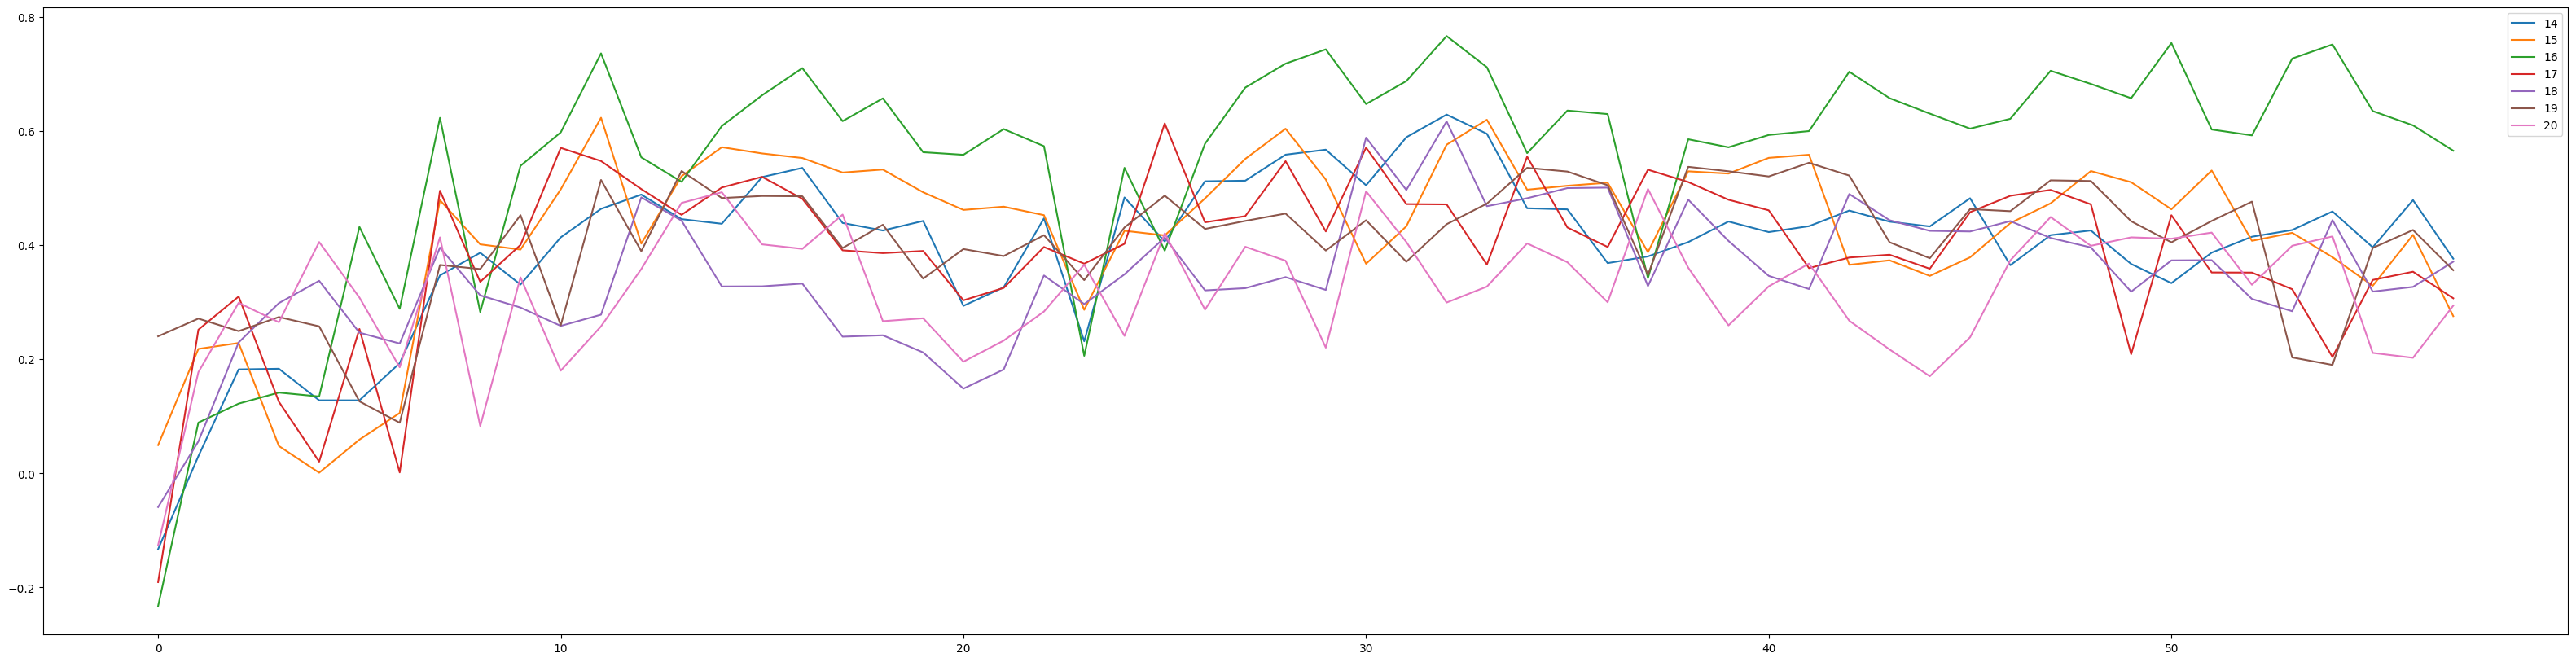

14 0.39803089079414977 0.13651654706375058 0.6288248896598816 -0.13291998207569122

15 0.4246165106265709 0.14536677191838676 0.6233391761779785 0.0011151880025863647

16 0.5526743757313696 0.19606889304861225 0.7665048837661743 -0.2326175719499588

17 0.38864262504824276 0.14413770536953868 0.613338828086853 -0.19069266319274902

18 0.34848388984542467 0.1164760579821334 0.6169214248657227 -0.059196606278419495

19 0.40567438407190914 0.10537751103683883 0.5443624258041382 0.08865123987197876

20 0.31978141619213696 0.11100526138029194 0.49843689799308777 -0.12601791322231293

in his third year, they were required to buy a particular textbook for Care of Magical Creatures, a book that was 
notorious for Who is Usain Bolt? Usain Bolt is a Jamaican sprinter who is widely regarded as the fastest man in the
world. He is an eight-time Olympic gold medalist and holds the world records in the 100 meters and 200 meters 
sprint events. Bolt was born

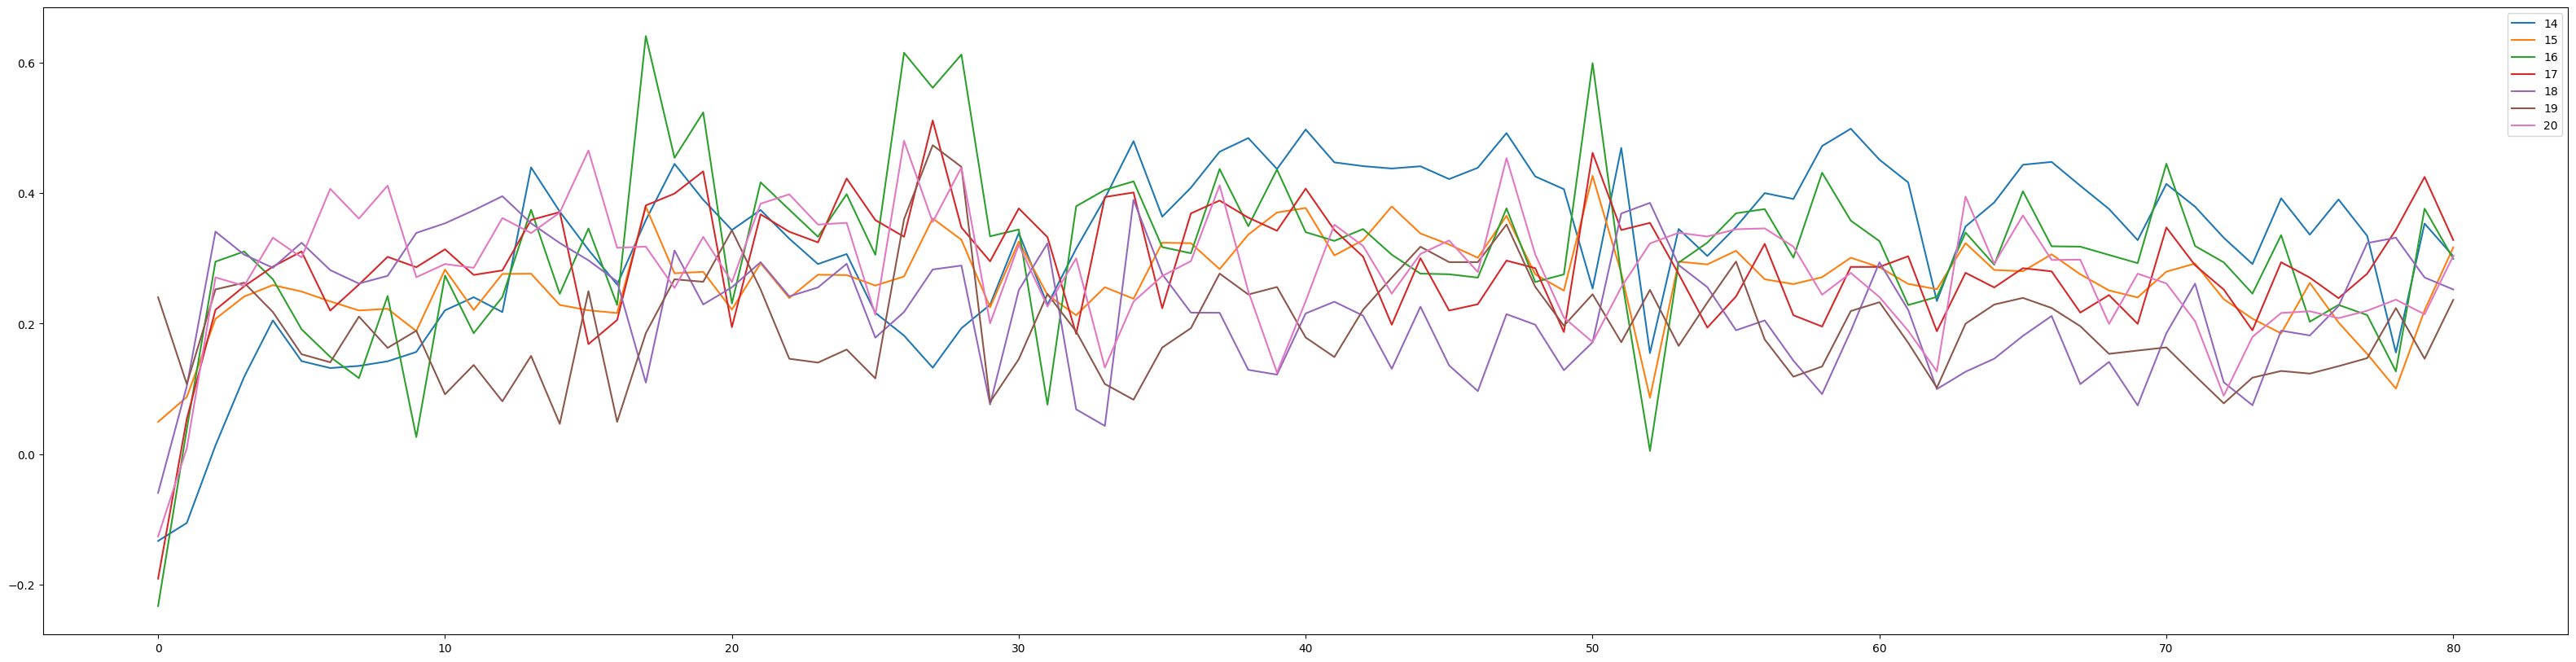

14 0.32308434176454204 0.13074016267192987 0.4984380006790161 -0.13292008638381958

15 0.265610615182438 0.06524285189068012 0.42620205879211426 0.04946768656373024

16 0.30979572149154583 0.13455961467308655 0.6403584480285645 -0.23261767625808716

17 0.2902078502064134 0.09407726140228019 0.5110151767730713 -0.19069267809391022

18 0.22190134700985603 0.09312228062593104 0.39506077766418457 -0.059196650981903076

19 0.19671173145373663 0.08085434288166927 0.4732135534286499 0.04641648009419441

20 0.28210098788510135 0.09596828452981775 0.47981488704681396 -0.12601806223392487

Who is Barack Obama? Barack Obama is the 44th President of the United States, serving two terms from 2009 to 2017. 
He is the first African American to hold the office. Prior to his presidency, Obama served as a United States 
Senator from Illinois

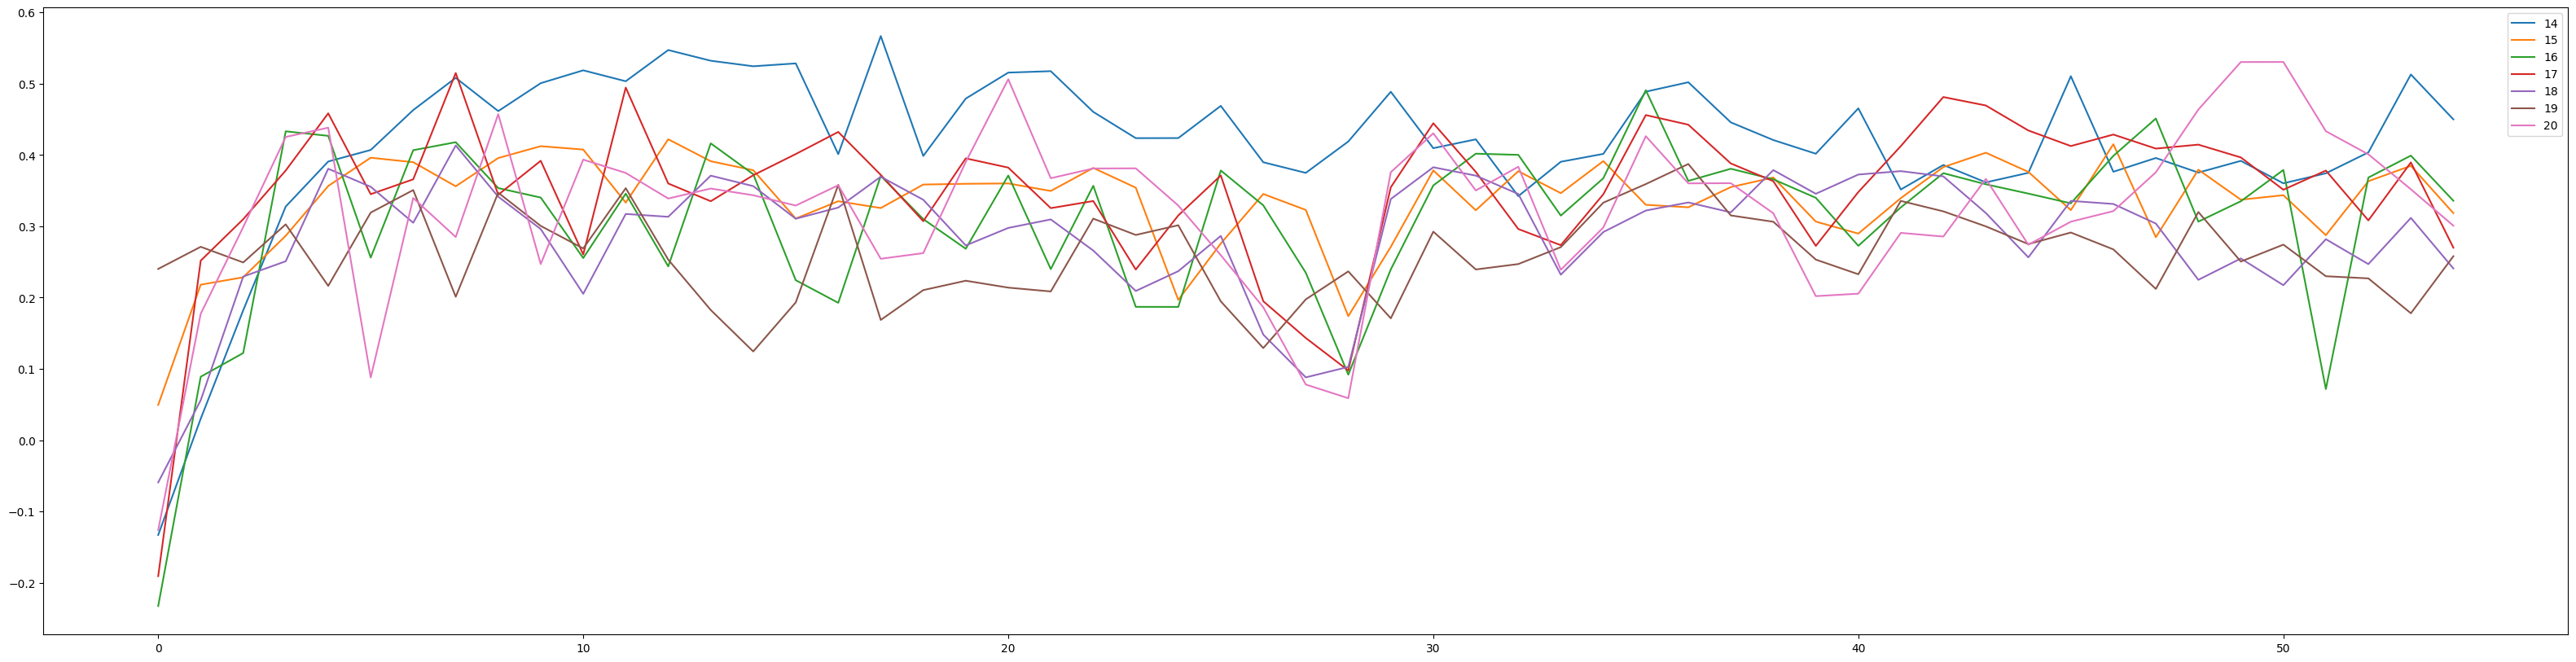

14 0.4170291254127568 0.1150244081831444 0.5668179392814636 -0.13291999697685242

15 0.33591395765542986 0.06597888088570548 0.42203477025032043 0.0494677796959877

16 0.3103427171707153 0.1181335608182117 0.49081769585609436 -0.2326176017522812

17 0.34948152181777087 0.10903244374376782 0.5149713754653931 -0.19069257378578186

18 0.287266409735788 0.08836307433797932 0.413318932056427 -0.05919657647609711

19 0.2611716687679291 0.06000964673371853 0.3873661756515503 0.12444624304771423

20 0.32288480157201943 0.1167485359911042 0.5304602384567261 -0.12601789832115173

Who is Harry Styles? Harry Styles is a British singer, songwriter, and actor who rose to fame as a member of the 
boy band One Direction. Born on February 1, 1994, in Redditch, Worcestershire, England, Styles began his career

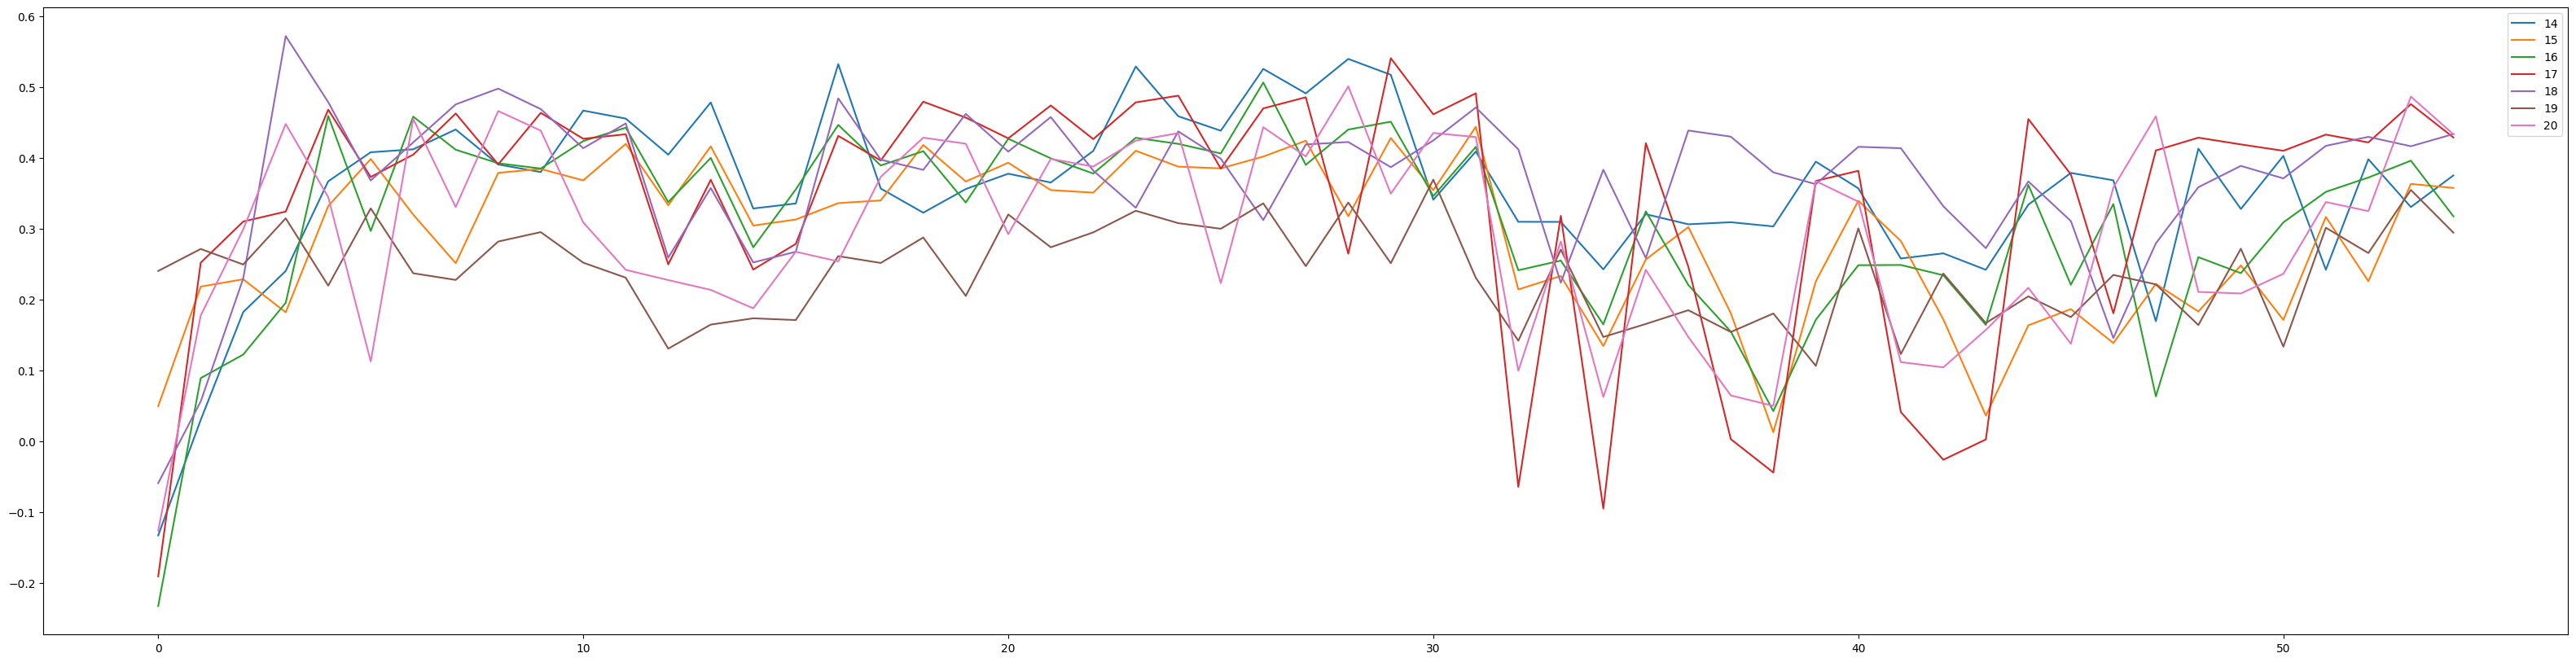

14 0.35460073118182744 0.11695519741699852 0.5393866300582886 -0.13291999697685242

15 0.29032110991803084 0.10557361785192983 0.4435875117778778 0.01265476644039154

16 0.31065035408193414 0.13289617326916223 0.5061299800872803 -0.2326176017522812

17 0.334434781155803 0.17570842036757334 0.5404274463653564 -0.19069257378578186

18 0.36932517676190896 0.10732797748825164 0.5716578960418701 -0.05919657647609711

19 0.23960846784439954 0.06552355209456431 0.3690813183784485 0.10628262162208557

20 0.29118450568480925 0.13718207709632585 0.5006603598594666 -0.12601789832115173

In [35]:
strengths = {target_layer: [] for target_layer in target_layers}

for p in track(prompts, total=len(prompts)):

    inputs = tokenizer(p, return_tensors="pt").input_ids
    outputs = model.generate(inputs.to(device), max_new_tokens=50, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        
    print (tokenizer.batch_decode(outputs, skip_special_tokens=True)[0])

    plt.figure(figsize=(40, 10))
    for target_layer in target_layers:
        plt.plot(strengths[target_layer], label=target_layer)
    plt.legend()
    plt.show()

    for target_layer in target_layers:
        print (target_layer, 
               np.mean(strengths[target_layer]), 
               np.std(strengths[target_layer]), 
               np.max(strengths[target_layer]),
               np.min(strengths[target_layer]))

    strengths = {target_layer: [] for target_layer in target_layers}
